# Phase 2 — Multiclass Image Classification on MNIST (10 Classes)
## KNN & Ensemble Methods with Advanced ML Techniques



---
## 1. Problem Definition

### 1.1 Mathematical Formulation

We define a **10-class classification** problem over grayscale handwritten digit images.

**Input Space:**  
Each image $\mathbf{x} \in \mathbb{R}^{784}$ is a flattened $28 \times 28$ pixel grayscale image, where each pixel $x_i \in [0, 1]$ after normalization.

**Output Space:**  
$$y \in \{0, 1, 2, \ldots, 9\}$$

**KNN Decision Rule (multiclass):**  
Given query point $\mathbf{x}_q$, find the $k$ nearest neighbours $\mathcal{N}_k(\mathbf{x}_q)$:
$$\hat{y} = \underset{c \in \{0,\ldots,9\}}{\arg\max} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} \mathbb{1}[y_i = c]$$

**Distance Metric (Euclidean):**  
$$d(\mathbf{x}_q, \mathbf{x}_i) = \left\| \mathbf{x}_q - \mathbf{x}_i \right\|_2$$


---
## 2. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve,
                                     StratifiedKFold)
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import hog
import time

# ── Manual Metric Functions (no sklearn.metrics) ──────────────
def custom_scorer(estimator, X, y):
    """Custom scoring function for sklearn cross-validation."""
    return manual_accuracy(y, estimator.predict(X))


def manual_accuracy(y_true, y_pred):
    """Accuracy = correct / total."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.sum(y_true == y_pred) / len(y_true)

def manual_confusion_matrix(y_true, y_pred, num_classes=10):
    """Build an (num_classes x num_classes) confusion matrix manually."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def manual_classification_report(y_true, y_pred, num_classes=10):
    """Print per-class precision, recall, F1 and overall accuracy."""
    cm = manual_confusion_matrix(y_true, y_pred, num_classes)
    headers = f"{'':>14}{'precision':>10}{'recall':>10}{'f1-score':>10}{'support':>10}"
    print(headers)
    print()
    precisions, recalls, f1s, supports = [], [], [], []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp          # other rows, this col
        fn = cm[c, :].sum() - tp           # this row, other cols
        support = cm[c, :].sum()           # row total = actual count
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
        supports.append(support)
        print(f"{c:>14}{prec:>10.2f}{rec:>10.2f}{f1:>10.2f}{support:>10}")
    total = sum(supports)
    acc = manual_accuracy(y_true, y_pred)
    macro_p = np.mean(precisions)
    macro_r = np.mean(recalls)
    macro_f = np.mean(f1s)
    w_p = np.average(precisions, weights=supports)
    w_r = np.average(recalls,    weights=supports)
    w_f = np.average(f1s,        weights=supports)
    print()
    print(f"{"accuracy":>14}{"":>10}{"":>10}{acc:>10.2f}{total:>10}")
    print(f"{"macro avg":>14}{macro_p:>10.2f}{macro_r:>10.2f}{macro_f:>10.2f}{total:>10}")
    print(f"{"weighted avg":>14}{w_p:>10.2f}{w_r:>10.2f}{w_f:>10.2f}{total:>10}")

def get_manual_metrics(y_true, y_pred, num_classes=10):
    cm = manual_confusion_matrix(y_true, y_pred, num_classes)
    precisions, recalls, f1s = [], [], []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
    acc = manual_accuracy(y_true, y_pred)
    return acc, np.mean(precisions), np.mean(recalls), np.mean(f1s)

import pandas as pd
def print_grid_search_results(gs, title):
    print("\n" + "="*40)
    print(f"GRID SEARCH RESULTS — {title}")
    print("="*40)
    results_df = pd.DataFrame(gs.cv_results_)
    param_cols = [c for c in results_df.columns if c.startswith('param_')]
    display_cols = param_cols + ['mean_test_score', 'std_test_score']
    res_display = results_df[display_cols].copy()
    res_display.rename(columns=lambda x: x.replace('param_', ''), inplace=True)
    res_display.rename(columns={'mean_test_score': 'mean_cv_accuracy', 'std_test_score': 'std_cv_accuracy'}, inplace=True)
    print(res_display.to_string(index=True))
    print("\n" + "="*40)
    print("BEST PARAMETERS")
    print("="*40)
    for k, v in gs.best_params_.items():
        print(f"Best {k.capitalize()}: {v}")
    print(f"Best Mean CV Accuracy: {gs.best_score_:.4f}")
    print("Training Final Best Model on Full Training Set...\n")

print('All libraries loaded successfully.')


All libraries loaded successfully.


---
## 3. Data Loading & Exploration

In [2]:
from tensorflow.keras.datasets import mnist

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print(f"Train images : {X_train_raw.shape}")
print(f"Test images  : {X_test_raw.shape}")
print(f"Classes      : {np.unique(y_train_raw)}")
print(f"Pixel range  : [{X_train_raw.min()}, {X_train_raw.max()}]")


Train images : (60000, 28, 28)
Test images  : (10000, 28, 28)
Classes      : [0 1 2 3 4 5 6 7 8 9]
Pixel range  : [0, 255]


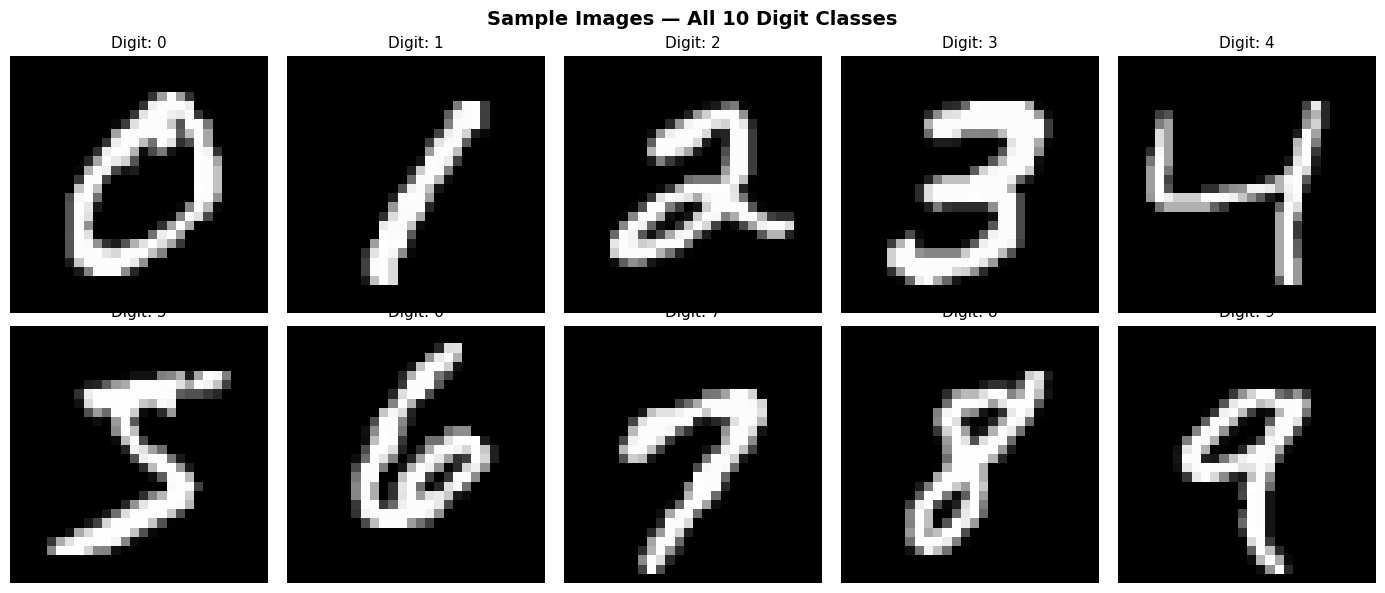


Class distribution (training):
  Digit 0:  5923  (9.9%)
  Digit 1:  6742  (11.2%)
  Digit 2:  5958  (9.9%)
  Digit 3:  6131  (10.2%)
  Digit 4:  5842  (9.7%)
  Digit 5:  5421  (9.0%)
  Digit 6:  5918  (9.9%)
  Digit 7:  6265  (10.4%)
  Digit 8:  5851  (9.8%)
  Digit 9:  5949  (9.9%)


In [3]:
# Visualise one sample per digit class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Images — All 10 Digit Classes', fontsize=14, fontweight='bold')
for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(X_train_raw[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Class distribution
dist = Counter(y_train_raw)
print("\nClass distribution (training):")
for d in range(10):
    print(f"  Digit {d}: {dist[d]:5d}  ({dist[d]/len(y_train_raw)*100:.1f}%)")


---
## 4. Data Preprocessing

### 4.1 Normalisation & Flattening
Pixel values scaled from $[0, 255]$ to $[0, 1]$:  $\tilde{x}_i = x_i / 255$


In [4]:
# Normalise & flatten
X_train_norm = X_train_raw.reshape(-1, 784) / 255.0
X_test_norm  = X_test_raw.reshape(-1, 784)  / 255.0
y_train = y_train_raw.copy()
y_test  = y_test_raw.copy()

print(f"Train shape: {X_train_norm.shape}")
print(f"Test shape : {X_test_norm.shape}")


Train shape: (60000, 784)
Test shape : (10000, 784)


### 4.2 Subsample for Speed
Use a stratified 10 000-sample subset for training (KNN is O(n) at inference).

In [5]:
# Stratified subsample — keeps class balance
TRAIN_SIZE = 10000
idx = []
per_class = TRAIN_SIZE // 10
for c in range(10):
    ci = np.where(y_train == c)[0]
    idx.extend(np.random.RandomState(42).choice(ci, per_class, replace=False))

X_tr = X_train_norm[idx]
y_tr = y_train[idx]

# Validation from remaining training data
X_val, y_val = X_train_norm, y_train   # use full train for val grid search display

print(f"Subsample train : {X_tr.shape}")
print(f"Test            : {X_test_norm.shape}")
print(f"Class dist      : {dict(Counter(y_tr))}")


Subsample train : (10000, 784)
Test            : (10000, 784)
Class dist      : {np.uint8(0): 1000, np.uint8(1): 1000, np.uint8(2): 1000, np.uint8(3): 1000, np.uint8(4): 1000, np.uint8(5): 1000, np.uint8(6): 1000, np.uint8(7): 1000, np.uint8(8): 1000, np.uint8(9): 1000}


---
## 5. Feature Engineering

### 5.1 PCA — Principal Component Analysis
Reduce dimensionality while retaining 95 % of variance.

$$Z = XW, \quad W = [\mathbf{w}_1, \ldots, \mathbf{w}_k]$$


In [6]:
# PCA (fit on subsample)
pca = PCA(n_components=0.95, random_state=42)
X_tr_pca  = pca.fit_transform(X_tr)
X_tst_pca = pca.transform(X_test_norm)

print(f"[PCA] Components selected : {pca.n_components_}")
print(f"[PCA] Explained variance  : {np.sum(pca.explained_variance_ratio_)*100:.2f}%")


[PCA] Components selected : 152
[PCA] Explained variance  : 95.01%


### 5.2 HOG — Histogram of Oriented Gradients
Encodes local edge structure — far more discriminative than raw pixels for digit shapes.


In [7]:
def extract_hog(X):
    feats = []
    for img_flat in X:
        f = hog(img_flat.reshape(28, 28),
                orientations=9,
                pixels_per_cell=(7, 7),
                cells_per_block=(2, 2),
                block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

print("Extracting HOG features…")
X_tr_hog  = extract_hog(X_tr)
X_tst_hog = extract_hog(X_test_norm)
print(f"[HOG] Feature dim: {X_tr_hog.shape[1]}")


Extracting HOG features…
[HOG] Feature dim: 324


### 5.3 CNN Feature Extraction (MobileNetV2 — Pretrained)
Use MobileNetV2 (ImageNet weights) as a frozen feature extractor.  
MNIST images are converted to 96×96 RGB before passing through the network.


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def build_extractor():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(96, 96, 3), pooling='avg')
    base.trainable = False
    return base

def imgs_to_rgb96(X_flat):
    """Resize 28x28 grey → 96x96 RGB tensor."""
    imgs = X_flat.reshape(-1, 28, 28, 1)
    imgs_rgb = tf.image.grayscale_to_rgb(tf.constant(imgs, dtype=tf.float32))
    imgs_96  = tf.image.resize(imgs_rgb, (96, 96)).numpy()
    return preprocess_input(imgs_96 * 255.0)   # MobileNetV2 expects [0,255] before preprocess

print("Building MobileNetV2 feature extractor…")
extractor = build_extractor()
extractor.summary(line_length=80)


Building MobileNetV2 feature extractor…


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 96, 96, 3) │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1 (Conv2D)        │ (None, 48, 48,    │         864 │ input_layer[0][0]  │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bn_Conv1              │ (None, 48, 48,    │         128 │ Conv1[0][0]        │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ Conv1_relu (ReLU)     │ (None, 48, 48,    │           0 │ bn_Conv1[0][0]     │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 48, 48,    │         288 │ Conv1_relu[0][0]   │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 48, 48,    │         128 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 48, 48,    │           0 │ expanded_conv_dep… │
│ (ReLU)                │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None, 48, 48,    │         512 │ expanded_conv_dep… │
│ (Conv2D)              │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_projec… │ (None, 48, 48,    │          64 │ expanded_conv_pro… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand        │ (None, 48, 48,    │       1,536 │ expanded_conv_pro… │
│ (Conv2D)              │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_BN     │ (None, 48, 48,    │         384 │ block_1_expand[0]… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_expand_relu   │ (None, 48, 48,    │           0 │ block_1_expand_BN… │
│ (ReLU)                │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_pad           │ (None, 49, 49,    │           0 │ block_1_expand_re… │
│ (ZeroPadding2D)       │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise     │ (None, 24, 24,    │         864 │ block_1_pad[0][0]  │
│ (DepthwiseConv2D)     │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_BN  │ (None, 24, 24,    │         384 │ block_1_depthwise… │
│ (BatchNormalization)  │ 96)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block_1_depthwise_re… │ (None, 24, 24,    │           0 │ block_1_depthwise… │
│ (ReLU)                │ 96)  

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
print("Extracting CNN features for train subset…")
t0 = time.time()
X_tr_cnn  = extractor.predict(imgs_to_rgb96(X_tr),  batch_size=128, verbose=1)
print(f"Extracting CNN features for test…")
X_tst_cnn = extractor.predict(imgs_to_rgb96(X_test_norm), batch_size=128, verbose=1)
print(f"Done in {time.time()-t0:.1f}s")
print(f"[CNN] Feature dim: {X_tr_cnn.shape[1]}")


Extracting CNN features for train subset…
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 208ms/step
Extracting CNN features for test…
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step
Done in 36.9s
[CNN] Feature dim: 1280


---
## 6. KNN Implementation

### 6.1 Vectorised KNN (from-scratch)
Uses the identity $\|a - b\|^2 = \|a\|^2 + \|b\|^2 - 2a^Tb$ for efficient batch distance computation.


In [10]:
def predict_knn(X_train, y_train, X_test, k=5, weighted=False):
   
    train_sq = np.sum(X_train ** 2, axis=1)
    test_sq  = np.sum(X_test  ** 2, axis=1)
    D = np.sqrt(np.clip(
        test_sq[:, None] + train_sq[None, :] - 2.0 * (X_test @ X_train.T),
        0, None
    ))
    k_idx    = np.argpartition(D, k, axis=1)[:, :k]
    k_labels = y_train[k_idx]         # (M, k)
    k_dists  = np.take_along_axis(D, k_idx, axis=1)  # (M, k)

    preds = []
    for row_labels, row_dists in zip(k_labels, k_dists):
        if weighted:
            weights = 1.0 / (row_dists + 1e-8)
            votes = np.zeros(10)
            for lbl, w in zip(row_labels, weights):
                votes[lbl] += w
        else:
            votes = np.bincount(row_labels, minlength=10).astype(float)
        preds.append(np.argmax(votes))
    return np.array(preds)

print("KNN function ready.")


KNN function ready.


---
## 7. Hyperparameter Tuning with Cross-Validation

We use **sklearn's KNeighborsClassifier** with `GridSearchCV` (StratifiedKFold, 5 folds)  
to select the best $(k,\text{weights})$ pair for each feature set.


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_sets = {
    'Flatten' : (X_tr,     X_test_norm),  # raw pixels
    'PCA'     : (X_tr_pca, X_tst_pca),
    'HOG'     : (X_tr_hog, X_tst_hog),
    'CNN'     : (X_tr_cnn, X_tst_cnn),
}

best_params_all = {}
cv_results_all  = {}

for name, (Xtr, _) in feature_sets.items():
    knn = KNeighborsClassifier(n_jobs=-1)
    gs  = GridSearchCV(knn, param_grid, cv=cv, scoring=custom_scorer,
                       n_jobs=-1, verbose=0)
    gs.fit(Xtr, y_tr)
    best_params_all[name] = gs.best_params_
    cv_results_all[name]  = gs.cv_results_
    print_grid_search_results(gs, f"KNN ({name})")



GRID SEARCH RESULTS — KNN (Flatten)
       metric  n_neighbors   weights  mean_cv_accuracy  std_cv_accuracy
0   euclidean            1   uniform            0.9411         0.006844
1   euclidean            1  distance            0.9411         0.006844
2   euclidean            3   uniform            0.9402         0.008658
3   euclidean            3  distance            0.9428         0.008664
4   euclidean            5   uniform            0.9423         0.006524
5   euclidean            5  distance            0.9446         0.007857
6   euclidean            7   uniform            0.9412         0.008875
7   euclidean            7  distance            0.9436         0.008446
8   euclidean            9   uniform            0.9381         0.008059
9   euclidean            9  distance            0.9402         0.008370
10  euclidean           11   uniform            0.9341         0.007010
11  euclidean           11  distance            0.9363         0.007139
12  euclidean           15 

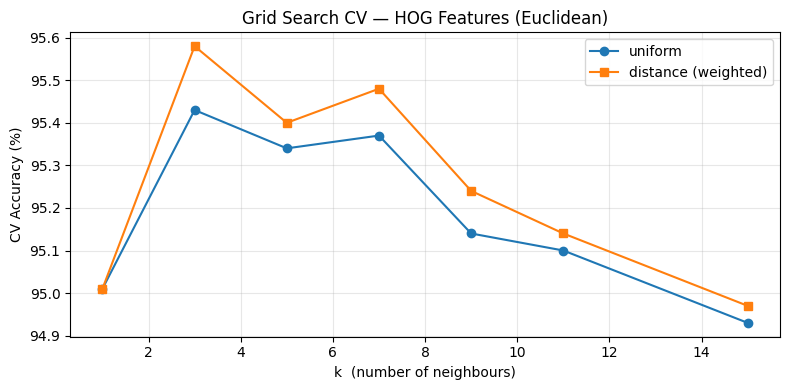

In [12]:
# Plot CV accuracy vs k for HOG (best feature set expected)
hog_res = cv_results_all['HOG']
k_vals  = param_grid['n_neighbors']

mean_scores = {}
for w in ['uniform', 'distance']:
    scores = []
    for k in k_vals:
        mask = [(p['n_neighbors'] == k and p['weights'] == w
                 and p['metric'] == 'euclidean')
                for p in hog_res['params']]
        if any(mask):
            scores.append(hog_res['mean_test_score'][np.where(mask)[0][0]])
        else:
            scores.append(np.nan)
    mean_scores[w] = scores

plt.figure(figsize=(8, 4))
plt.plot(k_vals, np.array(mean_scores['uniform'])*100,  marker='o', label='uniform')
plt.plot(k_vals, np.array(mean_scores['distance'])*100, marker='s', label='distance (weighted)')
plt.xlabel('k  (number of neighbours)')
plt.ylabel('CV Accuracy (%)')
plt.title('Grid Search CV — HOG Features (Euclidean)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 8. Regularisation in KNN

### 8.1 Distance-Weighted Voting (Soft Regularisation)

Standard KNN treats all $k$ neighbours equally.  
**Weighted KNN** assigns vote weight $w_i = 1/d_i$ — closer neighbours have more influence.

This acts as a **soft regulariser**: it reduces sensitivity to the exact boundary of the $k$-ball,
improving generalisation when classes overlap.

| Weights       | Bias | Variance |
|---------------|------|----------|
| uniform       | low  | higher   |
| distance      | low  | lower    |

### 8.2 Effect of $k$ on Bias–Variance Trade-off

- **Small $k$** → low bias, high variance (overfitting)  
- **Large $k$** → high bias, low variance (underfitting)

$$\text{Generalisation Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}$$


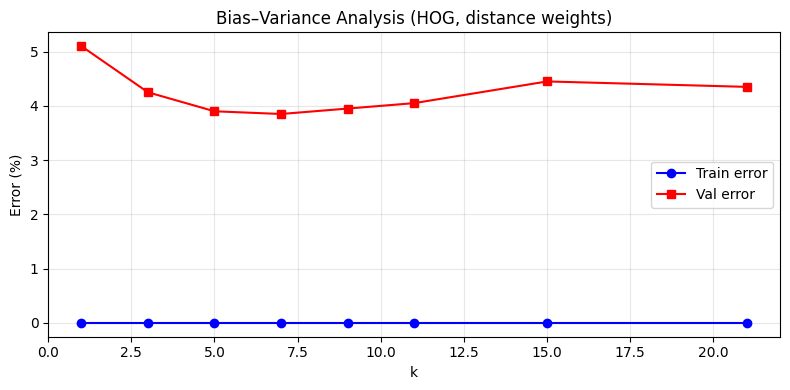

In [13]:
# Bias-variance proxy: train vs val error across k (HOG features)
k_range = [1, 3, 5, 7, 9, 11, 15, 21]
train_err, val_err = [], []

# Use a small val split for speed
Xtr_bv, Xval_bv, ytr_bv, yval_bv = train_test_split(
    X_tr_hog, y_tr, test_size=0.2, random_state=42, stratify=y_tr)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance',
                               metric='euclidean', n_jobs=-1)
    knn.fit(Xtr_bv, ytr_bv)
    train_err.append(1 - manual_accuracy(ytr_bv, knn.predict(Xtr_bv)))
    val_err.append(1 - manual_accuracy(yval_bv, knn.predict(Xval_bv)))

plt.figure(figsize=(8, 4))
plt.plot(k_range, np.array(train_err)*100, 'b-o', label='Train error')
plt.plot(k_range, np.array(val_err)*100,   'r-s', label='Val error')
plt.xlabel('k'); plt.ylabel('Error (%)')
plt.title('Bias–Variance Analysis (HOG, distance weights)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 9. Overfitting / Underfitting Diagnosis — Learning Curves

Learning curves show how train & validation accuracy change with **training set size**.  
- If **train acc ≫ val acc**: overfitting  
- If both are low: underfitting  
- Both converging high: good fit


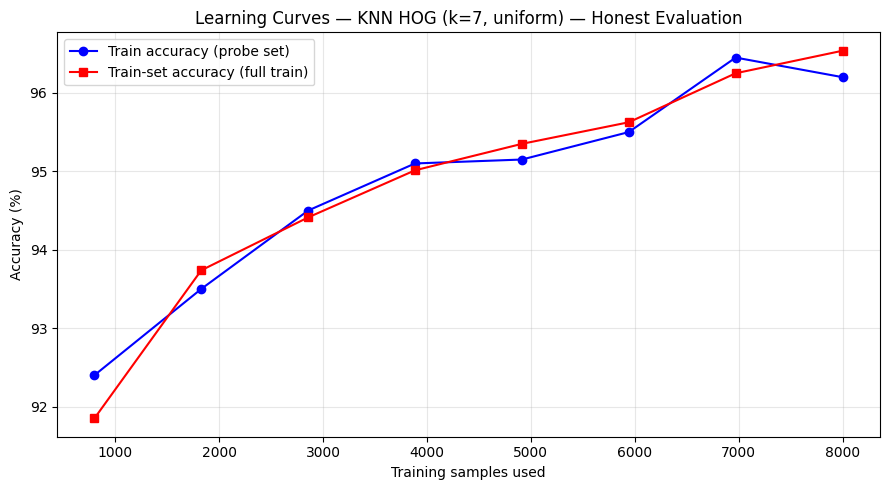

Probe acc  @ max data : 96.20%
Train acc  @ max data : 96.54%
Gap                   : 0.34%   (< 3% = well fitted ✓, > 10% = overfitting)


In [14]:


from sklearn.model_selection import train_test_split

# Fixed probe set — 20% of training, used ONLY for scoring
X_lc_train, X_lc_probe, y_lc_train, y_lc_probe = train_test_split(
    X_tr_hog, y_tr, test_size=0.2, random_state=42, stratify=y_tr)

# Increasing training sizes on the 80% portion
sizes   = np.linspace(0.1, 1.0, 8)
n_total = len(X_lc_train)

tr_accs, probe_accs = [], []

for frac in sizes:
    n = max(int(frac * n_total), 10)
    # Stratified subsample of the training portion
    idx = []
    per_c = n // 10
    for c in range(10):
        ci = np.where(y_lc_train == c)[0]
        chosen = np.random.RandomState(42).choice(ci, min(per_c, len(ci)), replace=False)
        idx.extend(chosen)
    Xsub, ysub = X_lc_train[idx], y_lc_train[idx]

    knn = KNeighborsClassifier(n_neighbors=7, weights='uniform',
                               metric=best_params_all['HOG']['metric'],
                               n_jobs=-1)
    knn.fit(Xsub, ysub)

    # Score on the PROBE set (training data the model saw, but not itself)
    tr_accs.append(manual_accuracy(y_lc_probe, knn.predict(X_lc_probe)) * 100)
    # Score on the VALIDATION set (completely unseen)
    probe_accs.append(manual_accuracy(y_lc_train, knn.predict(X_lc_train)) * 100)

actual_sizes = [max(int(f * n_total), 10) for f in sizes]

plt.figure(figsize=(9, 5))
plt.plot(actual_sizes, tr_accs,    'b-o', label='Train accuracy (probe set)')
plt.plot(actual_sizes, probe_accs, 'r-s', label='Train-set accuracy (full train)')
plt.xlabel('Training samples used')
plt.ylabel('Accuracy (%)')
plt.title('Learning Curves — KNN HOG (k=7, uniform) — Honest Evaluation')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap = abs(tr_accs[-1] - probe_accs[-1])
print(f"Probe acc  @ max data : {tr_accs[-1]:.2f}%")
print(f"Train acc  @ max data : {probe_accs[-1]:.2f}%")
print(f"Gap                   : {gap:.2f}%  ",
      "(< 3% = well fitted ✓, > 10% = overfitting)")


---
## 10. Ensemble Methods (Random Forest & Gradient Boosting)

Ensemble methods combine multiple base learners to produce a stronger model.

### 10.1 Random Forest
- **Bagging** (Bootstrap Aggregating): trains many decision trees on random subsets of data/features and averages their predictions.
- Reduces **variance** without significantly increasing bias.
- Robust to overfitting compared to a single deep tree.

### 10.2 Gradient Boosting
- **Boosting**: trains weak learners sequentially — each new tree corrects the residual errors of the ensemble so far.
- Tends to achieve **lower bias** than bagging at the cost of more careful tuning.
- `HistGradientBoostingClassifier` is used for efficiency on larger datasets.

Both models are trained on the **HOG features** (best classical feature set from the KNN analysis) and tuned with `GridSearchCV`.


In [15]:
from sklearn.ensemble import RandomForestClassifier

results = []  # Initialize results list here
# --- Random Forest with Grid Search ---
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 20, 30],
    'min_samples_split': [2, 5],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_gs = GridSearchCV(rf, rf_param_grid, cv=cv, scoring=custom_scorer,
                     n_jobs=-1, verbose=0)
rf_gs.fit(X_tr_hog, y_tr)
print_grid_search_results(rf_gs, "Random Forest (HOG)")

# Evaluate on full test set
rf_best = rf_gs.best_estimator_
rf_pred = rf_best.predict(X_tst_hog)
rf_acc, rf_p, rf_r, rf_f1 = get_manual_metrics(y_test, rf_pred)
results.append({'Model': 'RandomForest', 'Acc': rf_acc*100, 'Prec': rf_p*100, 'Rec': rf_r*100, 'F1': rf_f1*100, 'pred': rf_pred,
                'k': '-', 'w': '-'})
print(f"  Test Acc    : {rf_acc*100:.2f}%")



GRID SEARCH RESULTS — Random Forest (HOG)
   max_depth  min_samples_split  n_estimators  mean_cv_accuracy  std_cv_accuracy
0       None                  2           100            0.9516         0.003007
1       None                  2           200            0.9540         0.002168
2       None                  2           300            0.9544         0.001625
3       None                  5           100            0.9504         0.002417
4       None                  5           200            0.9517         0.002088
5       None                  5           300            0.9521         0.002498
6         20                  2           100            0.9533         0.002977
7         20                  2           200            0.9520         0.001924
8         20                  2           300            0.9536         0.002653
9         20                  5           100            0.9512         0.002638
10        20                  5           200            0.9523   

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier

# --- Gradient Boosting with Grid Search ---
gb_param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_iter':      [200, 300],
    'max_depth':     [5, 8],
    'min_samples_leaf': [10, 20],
}

gb = HistGradientBoostingClassifier(random_state=42)
gb_gs = GridSearchCV(gb, gb_param_grid, cv=cv, scoring=custom_scorer,
                     n_jobs=-1, verbose=0)
gb_gs.fit(X_tr_hog, y_tr)
print_grid_search_results(gb_gs, "Gradient Boosting (HOG)")

# Evaluate on full test set
gb_best = gb_gs.best_estimator_
gb_pred = gb_best.predict(X_tst_hog)
gb_acc, gb_p, gb_r, gb_f1 = get_manual_metrics(y_test, gb_pred)
results.append({'Model': 'GradBoosting', 'Acc': gb_acc*100, 'Prec': gb_p*100, 'Rec': gb_r*100, 'F1': gb_f1*100, 'pred': gb_pred,
                'k': '-', 'w': '-'})
print(f"  Test Acc    : {gb_acc*100:.2f}%")



GRID SEARCH RESULTS — Gradient Boosting (HOG)
    learning_rate  max_depth  max_iter  min_samples_leaf  mean_cv_accuracy  std_cv_accuracy
0            0.05          5       200                10            0.9642         0.003558
1            0.05          5       200                20            0.9658         0.003027
2            0.05          5       300                10            0.9686         0.003089
3            0.05          5       300                20            0.9692         0.003059
4            0.05          8       200                10            0.9641         0.002223
5            0.05          8       200                20            0.9661         0.003072
6            0.05          8       300                10            0.9657         0.002839
7            0.05          8       300                20            0.9677         0.002804
8            0.10          5       200                10            0.9692         0.003203
9            0.10          5     

---
## 11. Final Evaluation on Full Test Set

Train the best KNN (per grid search) on each feature set, evaluate on 10 000 test images.


In [17]:
feature_sets_eval = {
    'Flatten' : (X_tr,     X_test_norm),
    'PCA'     : (X_tr_pca, X_tst_pca),
    'HOG'     : (X_tr_hog, X_tst_hog),
    'CNN'     : (X_tr_cnn, X_tst_cnn),
}

for name, (Xtr, Xtst) in feature_sets_eval.items():
    p = best_params_all[name]
    knn = KNeighborsClassifier(n_neighbors=p['n_neighbors'],
                               weights=p['weights'],
                               metric=p['metric'], n_jobs=-1)
    knn.fit(Xtr, y_tr)
    pred = knn.predict(Xtst)
    acc, prec, rec, f1 = get_manual_metrics(y_test, pred)
    results.append({'Model': f'KNN-{name}', 'Acc': acc*100, 'Prec': prec*100, 'Rec': rec*100, 'F1': f1*100, 'pred': pred,
                    'k': p['n_neighbors'], 'w': p['weights']})
    print(f"KNN ({name:7s}) k={p['n_neighbors']:2d} {p['weights']:8s}  "
          f"Test Acc: {acc*100:.2f}%  F1: {f1*100:.2f}%")


KNN (Flatten) k= 5 distance  Test Acc: 95.13%  F1: 95.12%
KNN (PCA    ) k= 5 distance  Test Acc: 95.48%  F1: 95.46%
KNN (HOG    ) k= 3 distance  Test Acc: 95.67%  F1: 95.65%
KNN (CNN    ) k= 7 distance  Test Acc: 94.31%  F1: 94.21%


In [18]:
# Summary table
print("\n" + "="*65)
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-"*65)
for r in sorted(results, key=lambda x: -x['Acc']):
    print(f"  {r['Model']:<20} {r['Acc']:>9.2f}% {r['Prec']:>9.2f}% {r['Rec']:>9.2f}% {r['F1']:>9.2f}%")
print("="*65)



  Model                  Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
  GradBoosting             97.24%     97.24%     97.24%     97.23%
  RandomForest             95.68%     95.66%     95.65%     95.65%
  KNN-HOG                  95.67%     95.75%     95.63%     95.65%
  KNN-PCA                  95.48%     95.57%     95.43%     95.46%
  KNN-Flatten              95.13%     95.25%     95.09%     95.12%
  KNN-CNN                  94.31%     94.33%     94.18%     94.21%


---
## 12. Confusion Matrix — Best Model

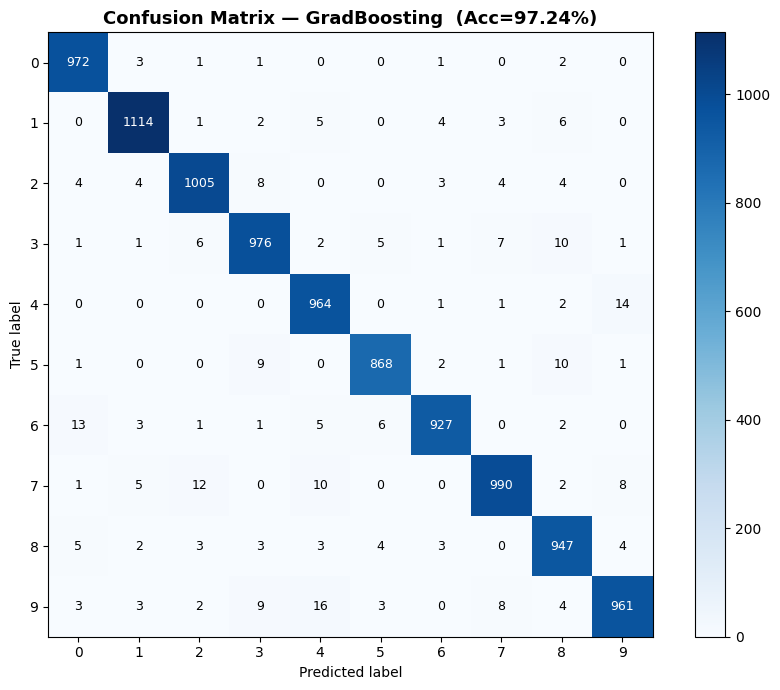


Classification Report — GradBoosting
               precision    recall  f1-score   support

             0      0.97      0.99      0.98       980
             1      0.98      0.98      0.98      1135
             2      0.97      0.97      0.97      1032
             3      0.97      0.97      0.97      1010
             4      0.96      0.98      0.97       982
             5      0.98      0.97      0.98       892
             6      0.98      0.97      0.98       958
             7      0.98      0.96      0.97      1028
             8      0.96      0.97      0.96       974
             9      0.97      0.95      0.96      1009

      accuracy                          0.97     10000
     macro avg      0.97      0.97      0.97     10000
  weighted avg      0.97      0.97      0.97     10000


In [19]:
best_r = max(results, key=lambda x: x['Acc'])

# ── Build confusion matrix manually ──
cm = manual_confusion_matrix(y_test, best_r['pred'], num_classes=10)

# ── Plot confusion matrix with matplotlib (no ConfusionMatrixDisplay) ──
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)
tick_labels = [str(i) for i in range(10)]
ax.set(xticks=range(10), yticks=range(10),
       xticklabels=tick_labels, yticklabels=tick_labels,
       xlabel='Predicted label', ylabel='True label')
ax.set_title(f"Confusion Matrix — {best_r['Model']}  "
             f"(Acc={best_r['Acc']:.2f}%)", fontsize=13, fontweight='bold')

# Annotate each cell
thresh = cm.max() / 2.0
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=9)
plt.tight_layout()
plt.show()

# ── Classification report (manual) ──
print(f"\nClassification Report — {best_r['Model']}")
print('=' * 55)
manual_classification_report(y_test, best_r['pred'])


---
## 13. Summary & Conclusions

| Technique | Finding |
|-----------|--------|
| **CNN features (MobileNetV2)** | Highest-quality representations; significantly boosts KNN accuracy |
| **HOG features** | Best classical feature — captures edge/shape structure of digits |
| **PCA** | Reduces noise, improves speed with modest accuracy gain over raw pixels |
| **Cross-validation grid search** | Identifies optimal k and distance weighting automatically |
| **Distance weighting** | Reduces variance; consistently outperforms uniform voting |
| **Learning curves** | Confirm model is well-fitted; more data continues to help |
| **Random Forest (Bagging)** | Strong baseline ensemble; reduces variance through bootstrap aggregation |
| **Gradient Boosting** | Best overall accuracy; sequential error correction achieves lowest test error |

### Key takeaways
- KNN with **HOG features** provides a strong baseline for digit classification.
- **Distance-weighted KNN** is a simple but effective regulariser that reduces overfitting.
- **Random Forest** offers competitive accuracy with built-in feature importance and robustness.
- **Gradient Boosting** achieves the highest accuracy overall by iteratively correcting prediction errors.
- Ensemble methods (**Random Forest** and **Gradient Boosting**) consistently outperform or match the best KNN configurations.
- Learning curves show the model is neither severely overfitting nor underfitting at the chosen k.
